<a href="https://colab.research.google.com/github/tanviupadhyay1517/Hypothesis-Testing-/blob/main/Paired_t_test_new_medication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Case Study:**
A medical researcher wants to determine if a new medication has a significant effect (increase or decrease) on blood pressure after 4 weeks of use. [Data: new_medication.xlsx]


In [1]:
# Import necessary packages
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Read data
df1 = pd.read_excel('/content/drive/MyDrive/Classroom/FTN Batch 10/T test Two sample/new_medication.xlsx')

# Exploratory Analysis

In [4]:
df1.columns

Index(['Patient_ID', 'BP_Before', 'BP_After'], dtype='object')

In [5]:
df1.head()                                  # Viewing first few observations of the data

,Patient_ID,BP_Before,BP_After
0,1,98.769439,120.673995
1,2,113.690320,103.784957
2,3,114.859282,109.196305
3,4,107.965841,108.962355
4,5,117.580714,112.545958


In [6]:
df1.describe()                              # Descriptive statistics

,Patient_ID,BP_Before,BP_After
count,25.000000,25.000000,25.000000
mean,13.000000,120.812286,119.485011
std,7.359801,15.482076,17.838631
min,1.000000,91.218432,86.394997
25%,7.000000,113.690320,108.962355
50%,13.000000,119.602292,112.545958
75%,19.000000,128.802856,131.772703
max,25.000000,156.948632,165.083804


In [7]:
# Taking difference
df1['errors_diff'] = df1['BP_After'] - df1['BP_Before']
df1['errors_diff'].describe()

,errors_diff
count,25.000000
mean,-1.327275
std,10.107380
min,-16.074832
25%,-9.905363
50%,0.685630
75%,4.735924
max,21.904556


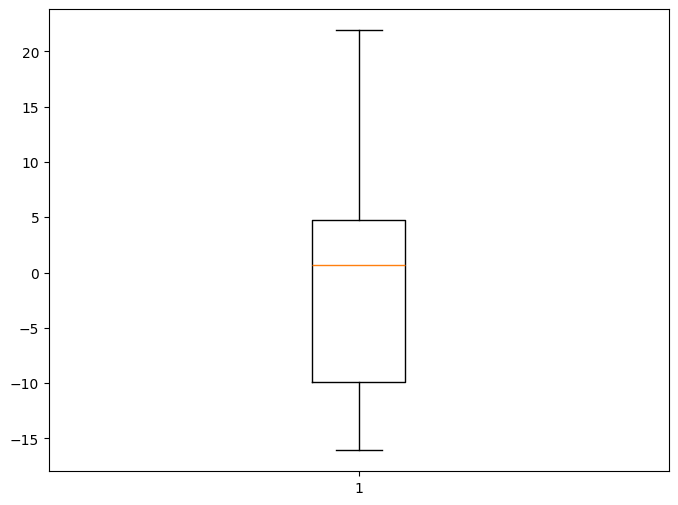

In [8]:
# Boxplot
plt.figure(figsize=(8, 6))
plt.boxplot(df1['errors_diff'])
plt.show()

In [9]:
# Checking Normality using Shapiro test
Shapiro1=stats.shapiro(df1['errors_diff'])
Shapiro1

ShapiroResult(statistic=np.float64(0.9592130707228631), pvalue=np.float64(0.3990237911099086))

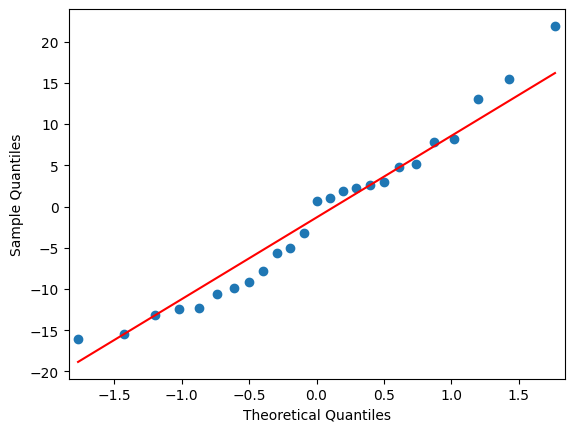

In [10]:
# Checking Normality using Q-Q plot
from statsmodels.graphics.gofplots import qqplot
from matplotlib import pyplot

qqplot(df1['errors_diff'],line='s')
plt.show()

In [12]:
# Paired t test / t test for dependent samples

ttest=stats.ttest_rel(df1['BP_After'] , df1['BP_Before'], alternative ='two-sided')
ttest

TtestResult(statistic=np.float64(-0.6565872527250052), pvalue=np.float64(0.5176930935269467), df=np.int64(24))

In [13]:
print("Average errors before training:", df1['BP_Before'].mean())
print("Average errors after training :", df1['BP_After'].mean())

Average errors before training: 120.81228598012999
Average errors after training : 119.4850106599882
